## Refraction

### Snell's Law
Snell's law relates the angle of incidence $\alpha$ and the angle of refraction $\beta$ through

$$n_A \sin(\alpha) = n \sin(\beta).$$

Since the refractive index of air is approximately $n_A \approx 1$, this becomes

$$\sin(\alpha) = n \sin(\beta),$$

where $n$ is the refractive index of the glass prism relative to air.

#### Graphing $\sin\alpha$ vs. $\sin\beta$
If we plot $y = \sin(\alpha)$ against $x = \sin(\beta)$, the formula becomes
$$y = n x,$$
We thus expect to get a linear function whose slope ($y' = (n x)'$) is the refractive index ($(n x)' = n$).

The uncertainty of the sine values is obtained by Gaussian error propagation,

$$d(\sin\theta) = |\cos\theta| \, d\theta,$$

with the angular uncertainty expressed in radians.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.odr import Model, ODR, RealData

# Enter the measured angles in degrees.
alpha = np.array([60, 39, 21, 7, 13.5, 32.5, 47.5, 27])  # angle of incidence
beta = np.array([37, 26, 14, 5, 11.5, 21, 31, 19])   # angle of refraction

dalpha = 2.0  # uncertainty of alpha in degrees
dbeta = 2.0   # uncertainty of beta in degrees

def require_data(*arrays):
    if any(np.size(arr) == 0 for arr in arrays):
        raise ValueError('Enter your measured data in the arrays before running the analysis cells.')

def line_through_origin(x, m):
    return m * x

def odr_line_through_origin(beta, x):
    return beta[0] * x

def constant_model(x, c):
    x = np.asarray(x)
    return np.full_like(x, c, dtype=float)

def displacement_model(alpha_deg, n, width_cm):
    alpha_rad = np.deg2rad(alpha_deg)
    beta_rad = np.arcsin(np.clip(np.sin(alpha_rad) / n, -1, 1))
    return width_cm * np.sin(alpha_rad - beta_rad) / np.cos(beta_rad)

require_data(alpha, beta)

if alpha.shape != beta.shape:
    raise ValueError('alpha and beta must have the same length.')

alpha_rad = np.deg2rad(alpha)
beta_rad = np.deg2rad(beta)
dalpha_rad = np.deg2rad(dalpha)
dbeta_rad = np.deg2rad(dbeta)

sin_alpha = np.sin(alpha_rad)
sin_beta = np.sin(beta_rad)
dsin_alpha = np.abs(np.cos(alpha_rad)) * dalpha_rad
dsin_beta = np.abs(np.cos(beta_rad)) * dbeta_rad

n_point = sin_alpha / sin_beta
dn_point = n_point * np.sqrt((dsin_alpha / sin_alpha)**2 + (dsin_beta / sin_beta)**2)


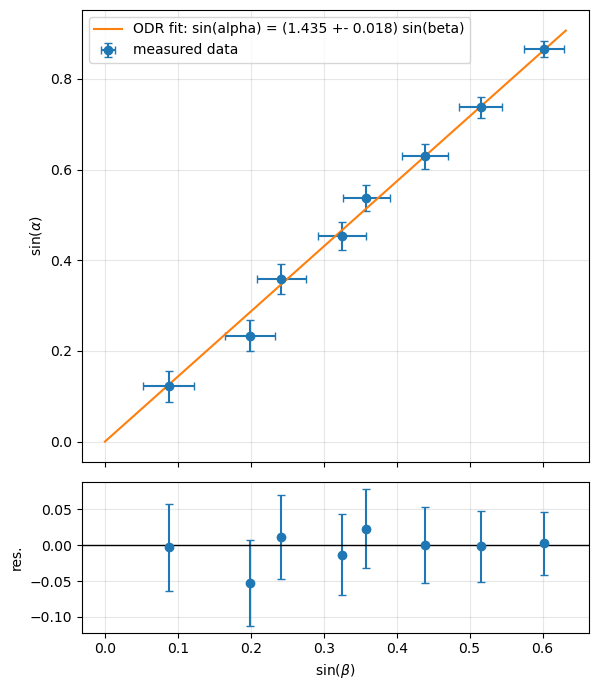

In [43]:
sin_data = RealData(sin_beta, sin_alpha, sx=dsin_beta, sy=dsin_alpha)
sin_model = Model(odr_line_through_origin)
sin_odr = ODR(sin_data, sin_model, beta0=[1.5])
sin_output = sin_odr.run()

n_sin = sin_output.beta[0]
dn_sin = sin_output.sd_beta[0]

sin_beta_fit = np.linspace(0, 1.05 * np.max(sin_beta), 300)
sin_alpha_fit = line_through_origin(sin_beta_fit, n_sin)
residuals_sin = sin_alpha - line_through_origin(sin_beta, n_sin)
dresiduals_sin = np.sqrt(dsin_alpha**2 + (n_sin * dsin_beta)**2)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(sin_beta, sin_alpha, xerr=dsin_beta, yerr=dsin_alpha, fmt='o', capsize=3, label='measured data')
ax.plot(sin_beta_fit, sin_alpha_fit, label=f'ODR fit: sin(alpha) = ({n_sin:.3f} +- {dn_sin:.3f}) sin(beta)')
ax.set_ylabel(r'$\sin(\alpha)$')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(sin_beta, residuals_sin, yerr=dresiduals_sin, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\sin(\beta)$')
ax_res.set_ylabel('res.')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Refractive Index
From Snell's law in the form $\sin(\alpha) = n \sin(\beta)$, the slope of the graph $\sin(\alpha)$ vs. $\sin(\beta)$ is directly equal to the refractive index $n$ of the material relative to air. We expect a value larger than 1 as the prism is an optically denser medium.

In [44]:
print(f'Refractive index: n = {n_sin:.3f} +- {dn_sin:.3f}')

Refractive index: n = 1.435 +- 0.018


#### Fit Discussion
Examining the residual plot, we see that all measurements are within the error margins / all error bars overlap with the linear fit. This indicates consistent measurements and a good fit to the data.

#### Graphing $\beta$ vs. $\alpha$

From Snell's law with air outside the prism,

$$\sin(\alpha) = n\sin(\beta),$$

we get

$$\beta(\alpha) = \arcsin\!\left(\frac{\sin(\alpha)}{n}\right).$$

This is in contrast to the sin graphs from above not linear.

Because the prism is optically denser than air, one expects $n>1$ and therefore $\beta < \alpha$ for all measured points. The graph should therefore show a rising curve below the line $\beta = \alpha$.

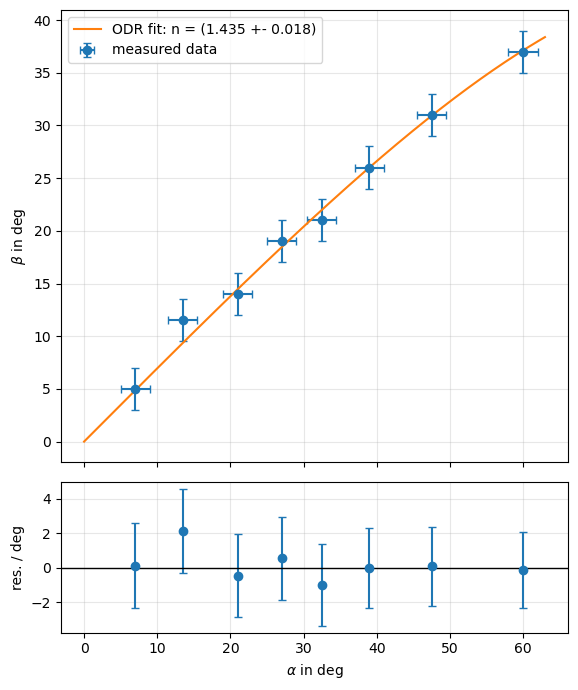

In [45]:
def beta_from_alpha_model(params, alpha_deg):
    n = params[0]
    alpha_rad = np.deg2rad(alpha_deg)
    beta_rad = np.arcsin(np.clip(np.sin(alpha_rad) / n, -1, 1))
    return np.rad2deg(beta_rad)

alpha_sigma = np.full_like(alpha, dalpha, dtype=float)
beta_sigma = np.full_like(beta, dbeta, dtype=float)

beta_data = RealData(alpha, beta, sx=alpha_sigma, sy=beta_sigma)
beta_model = Model(beta_from_alpha_model)
beta_odr = ODR(beta_data, beta_model, beta0=[n_sin])
beta_output = beta_odr.run()

n_beta = beta_output.beta[0]
dn_beta = beta_output.sd_beta[0]

alpha_fit = np.linspace(0, 1.05 * np.max(alpha), 300)
beta_fit = beta_from_alpha_model([n_beta], alpha_fit)
residuals_beta = beta - beta_from_alpha_model([n_beta], alpha)

h_alpha = max(dalpha, 1e-6)
dbeta_dalpha = (
    beta_from_alpha_model([n_beta], alpha + h_alpha) - beta_from_alpha_model([n_beta], alpha - h_alpha)
) / (2 * h_alpha)
dresiduals_beta = np.sqrt(beta_sigma**2 + (dbeta_dalpha * alpha_sigma)**2)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(alpha, beta, xerr=dalpha, yerr=dbeta, fmt='o', capsize=3, label='measured data')
ax.plot(alpha_fit, beta_fit, label=f'ODR fit: n = ({n_beta:.3f} +- {dn_beta:.3f})')
ax.set_ylabel(r'$\beta$ in deg')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(alpha, residuals_beta, yerr=dresiduals_beta, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\alpha$ in deg')
ax_res.set_ylabel('res. / deg')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Refractive Index
In this fit, the refractive index $n$ is itself the fit parameter of the model

$$\beta(\alpha) = \arcsin\!\left(\frac{\sin(\alpha)}{n}\right).$$

The value returned by the fit therefore directly gives the refractive index of the prism relative to air. Its uncertainty is obtained from the fit uncertainty of the parameter $n$.



In [46]:
print(f'Refractive index from the beta-vs-alpha fit: n = {n_beta:.3f} +- {dn_beta:.3f}')
print(f'Difference to part a): Delta n = {n_beta - n_sin:.3f}')

Refractive index from the beta-vs-alpha fit: n = 1.435 +- 0.018
Difference to part a): Delta n = 0.000


#### Discussion
As expected we get a slightly sublinear graph. Fitting the function we derived above to the measurements, we get a very good fit, all measurements are within the error margins. Comparing the fit parameters/refractive indices of this and the previous calculation, we get a perfect correspondance.

This strongly indicates that the derivations we used to get the function are correct.

### Parallel displacement
For a ray that gets refracted in a rectangular prism, the exit angle is the same as the incident angle, the ray has just been orthogonaly shifted by a distance d.

The distance $s$ the ray travelled inside the prism can be found as follwed:
$\cos(\beta) = \frac {AK}{HYP} = \frac{w}{s} \Rightarrow s = \frac{w}{\cos(\beta)}$

We can then find the component of this distance that is travelled orthogonally to the incident ray using $\sin(\alpha - \sin(\beta))$, giving us the formula $$d = w \cdot \frac{\sin(\alpha - \beta)}{\cos(\beta)}$$. 

We can solve snells law for $\beta$ as follows: $$\sin(\alpha) = n \sin(\beta) \Rightarrow \beta = \arcsin(\frac{\sin(\alpha)}{n})$$

Plugging this into the above formula we get: $$d = w \cdot \frac{\sin(\alpha - \arcsin(\frac{\sin(\alpha)}{n}))}{\cos(\arcsin(\frac{\sin(\alpha)}{n}))}$$


For one selected measurement point, the predicted displacement and its absolute uncertainty are calculated below using Gaussian uncertainty propagation.

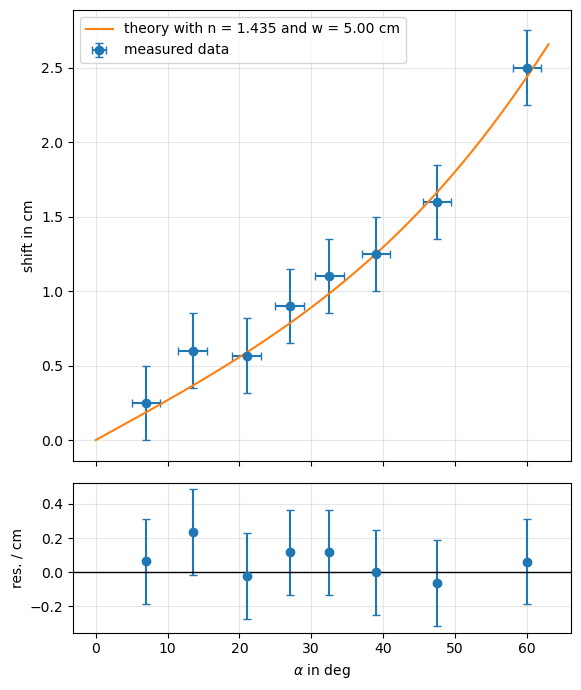

Predicted displacement for point 0: s = 2.438 +- 0.164 cm
Measured displacement for point 0: s_meas = 2.500 +- 0.250 cm
Difference: Delta s = 0.062 +- 0.299 cm


In [47]:
# Enter the measurements for the parallel displacement here.
alpha_shift = alpha  # angle of incidence in degrees
shift = np.array([2.5, 1.25, 0.567, 0.25, 0.6, 1.1, 1.6, 0.9])         # parallel displacement in cm
dshift = 0.25                # uncertainty of the displacement in cm

# Width of the prism / glass block in cm.
w = 5.0 # TODO
dw = 0.15

# Index of the data point for the explicit prediction.
point_index = 0

require_data(alpha_shift, shift)

if alpha_shift.shape != shift.shape:
    raise ValueError('alpha_shift and shift must have the same length.')
if w <= 0:
    raise ValueError('Enter the prism width in the variable w.')
if not (0 <= point_index < len(alpha_shift)):
    raise ValueError('point_index is outside the valid range.')

alpha_shift_fit = np.linspace(0, 1.05 * np.max(alpha_shift), 300)
shift_theory = displacement_model(alpha_shift_fit, n_sin, w)
shift_residuals = shift - displacement_model(alpha_shift, n_sin, w)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(alpha_shift, shift, xerr=dalpha, yerr=dshift, fmt='o', capsize=3, label='measured data')
ax.plot(alpha_shift_fit, shift_theory, label=f'theory with n = {n_sin:.3f} and w = {w:.2f} cm')
ax.set_ylabel('shift in cm')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(alpha_shift, shift_residuals, yerr=dshift, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\alpha$ in deg')
ax_res.set_ylabel('res. / cm')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

alpha0 = alpha_shift[point_index]
alpha0_rad = np.deg2rad(alpha0)
beta0_rad = np.arcsin(np.clip(np.sin(alpha0_rad) / n_sin, -1, 1))
s0 = displacement_model(alpha0, n_sin, w)

# Numerical partial derivatives for Gaussian error propagation.
h_alpha = max(np.deg2rad(dalpha), 1e-6)
h_n = max(dn_sin, 1e-6)
h_w = max(dw, 1e-6)

def displacement_rad(alpha_rad, n, width_cm):
    beta_rad = np.arcsin(np.clip(np.sin(alpha_rad) / n, -1, 1))
    return width_cm * np.sin(alpha_rad - beta_rad) / np.cos(beta_rad)

ds_dalpha = (displacement_rad(alpha0_rad + h_alpha, n_sin, w) - displacement_rad(alpha0_rad - h_alpha, n_sin, w)) / (2 * h_alpha)
ds_dn = (displacement_rad(alpha0_rad, n_sin + h_n, w) - displacement_rad(alpha0_rad, n_sin - h_n, w)) / (2 * h_n)
ds_dw = (displacement_rad(alpha0_rad, n_sin, w + h_w) - displacement_rad(alpha0_rad, n_sin, w - h_w)) / (2 * h_w)

ds0 = np.sqrt((ds_dalpha * np.deg2rad(dalpha))**2 + (ds_dn * dn_sin)**2 + (ds_dw * dw)**2)
difference = shift[point_index] - s0
ddifference = np.sqrt(dshift**2 + ds0**2)

print(f'Predicted displacement for point {point_index}: s = {s0:.3f} +- {ds0:.3f} cm')
print(f'Measured displacement for point {point_index}: s_meas = {shift[point_index]:.3f} +- {dshift:.3f} cm')
print(f'Difference: Delta s = {difference:.3f} +- {ddifference:.3f} cm')

#### Discussion
As measuring the parallel displacement is quite hard and prone to errors, i.e. non-parallel line extensions and then measurement errors, we opted for a reasonably high uncertainty of 2.5mm.

With this, the graph of the function we derived above went through all of our measured data points (including error bars), indicating that the derivation is correct and the data points were, within the uncertainty, well measured.

Examining the first point specifically, we only observe a small discrepancy to the expected/theoretical value, although with the previously mentioned high uncertainty.

TODO: extend the above with additional task 1, adding a fitted function instead of just the theoretical one. then compare the two.